In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from copy import deepcopy
import pandas as pd
import warnings

In [3]:
warnings.filterwarnings('ignore')

In [4]:
RANDOM_SEED = 1337
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [5]:
N_TRAIN = 500
N_TEST = 500
VAL_SIZE = 0.2
PATIENCE = 50
BATCH_SIZE = 64
EPOCHS = 1000
LR = 1e-3
HIDDEN_DIM = 128
L1_LAMBDAS = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
L2_LAMBDAS = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
LR_C_VALUES = [0.01, 0.1, 1, 10, 100]

In [6]:
def make_moons_custom(n_samples, noise=0.2, random_state=None):
    if random_state:
        rng = np.random.default_rng(random_state)
    else:
        rng = np.random.default_rng()

    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out
    
    outer_t = np.linspace(0, np.pi, n_samples_out)
    outer_x = np.cos(outer_t)
    outer_y = np.sin(outer_t)
    X_outer = np.vstack([outer_x, outer_y]).T
    y_outer = np.zeros(n_samples_out)
    
    inner_t = np.linspace(0, np.pi, n_samples_in)
    inner_x = 1 - np.cos(inner_t)
    inner_y = 1 - np.sin(inner_t) - 0.5
    X_inner = np.vstack([inner_x, inner_y]).T
    y_inner = np.ones(n_samples_in)
    
    X = np.vstack([X_outer, X_inner])
    y = np.hstack([y_outer, y_inner])
    
    if noise > 0:
        X += rng.normal(scale=noise, size=X.shape)
        
    return X, y.astype(int)

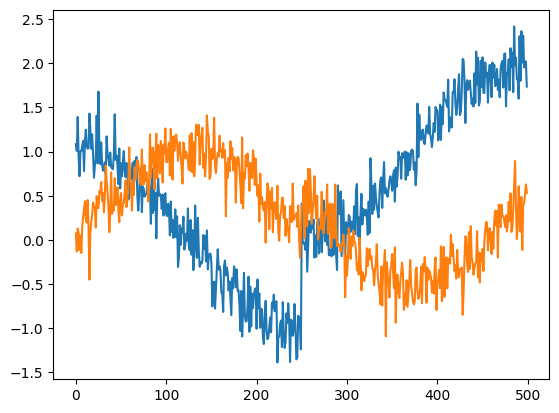

In [7]:
X, y = make_moons_custom(n_samples=N_TRAIN)
plt.plot(X)

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=HIDDEN_DIM):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.layer2(x)
        return x

In [9]:
def calculate_sparsity(model, threshold=1e-4):
    sparsities = {}
    total_weights = 0
    total_sparse = 0
    
    for name, param in model.named_parameters():
        if 'weight' in name:
            layer_weights = param.data.numel()
            layer_sparse = (torch.abs(param.data) < threshold).sum().item()
            sparsities[name] = layer_sparse / layer_weights
            total_weights += layer_weights
            total_sparse += layer_sparse
            
    sparsities['total'] = total_sparse / total_weights if total_weights > 0 else 0
    return sparsities

In [10]:
def train_model(model, X_train, y_train, X_val, y_val, l1_lambda=0.0, l2_lambda=0.0):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=l2_lambda)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            if l1_lambda > 0:
                l1_norm = sum(torch.abs(param).sum() for name, param in model.named_parameters() if 'weight' in name)
                loss += l1_lambda * l1_norm
                
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            
            if l1_lambda > 0:
                l1_norm = sum(torch.abs(param).sum() for name, param in model.named_parameters() if 'weight' in name)
                val_loss += l1_lambda * l1_norm

        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == PATIENCE:
                # print(f"Early stopping at epoch {epoch+1}")
                break
                
    model.load_state_dict(best_model_state)
    return model

In [11]:
def get_model_predictions(model, X, is_torch=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    if is_torch:
        model.eval()
        with torch.no_grad():
            logits = model(X_t)
            probs = torch.sigmoid(logits).numpy().ravel()
    else: 
        probs = model.predict_proba(X)[:, 1]
    return probs

In [12]:
def plot_decision_boundary(ax, model, X, y, title, is_torch=True):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid_data = np.c_[xx.ravel(), yy.ravel()]
    Z = get_model_predictions(model, grid_data, is_torch=is_torch)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

In [13]:
def run_experiment(X_train_raw, y_train, test_sets):

    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train_raw, y_train, test_size=VAL_SIZE, random_state=RANDOM_SEED
    )
    
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train_sub)
    X_val_std = scaler.transform(X_val)

    test_sets_std = {}
    for name, (X, y) in test_sets.items():
        test_sets_std[name] = (scaler.transform(X), y)

    all_models = {}
    eval_results = {}
    
    print("Training Model 1: MLP (Early Stopping)...")
    model_es = MLP()
    model_es = train_model(model_es, X_train_std, y_train_sub, X_val_std, y_val)
    all_models['MLP-ES'] = (model_es, True) # (model, is_torch)
    
    
    print("Training Model 2: MLP (L1 Grid Search)...")
    l1_results = []
    best_l1_auroc = -1
    best_l1_model = None
    
    for l1 in L1_LAMBDAS:
        model_l1 = MLP()
        model_l1 = train_model(model_l1, X_train_std, y_train_sub, X_val_std, y_val, l1_lambda=l1)
        
        val_preds = get_model_predictions(model_l1, X_val_std)
        val_auroc = roc_auc_score(y_val, val_preds)
        sparsity = calculate_sparsity(model_l1)
        
        l1_results.append({
            'lambda': l1,
            'val_auroc': val_auroc,
            'sparsity_l1': sparsity['layer1.weight'],
            'sparsity_l2': sparsity['layer2.weight'],
            'sparsity_total': sparsity['total']
        })
        
        if val_auroc > best_l1_auroc:
            best_l1_auroc = val_auroc
            best_l1_model = deepcopy(model_l1)
            
    all_models['MLP-L1'] = (best_l1_model, True)
    l1_df = pd.DataFrame(l1_results)

    print("Training Model 3: MLP (L2 Grid Search)...")
    best_l2_auroc = -1
    best_l2_model = None
    
    for l2 in L2_LAMBDAS:
        model_l2 = MLP()
        model_l2 = train_model(model_l2, X_train_std, y_train_sub, X_val_std, y_val, l2_lambda=l2)
        
        val_preds = get_model_predictions(model_l2, X_val_std)
        val_auroc = roc_auc_score(y_val, val_preds)
        
        if val_auroc > best_l2_auroc:
            best_l2_auroc = val_auroc
            best_l2_model = deepcopy(model_l2)
            
    all_models['MLP-L2'] = (best_l2_model, True)

    print("Training Model 4: Logistic Regression (Poly)...")
    
    poly_scaler_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scaler', StandardScaler())
    ])
    
    X_train_poly = poly_scaler_pipe.fit_transform(X_train_std)
    X_val_poly = poly_scaler_pipe.transform(X_val_std)
    
    best_lr_auroc = -1
    best_lr_model = None
    
    for c in LR_C_VALUES:
        model_lr = LogisticRegression(C=c, solver='liblinear', random_state=RANDOM_SEED)
        model_lr.fit(X_train_poly, y_train_sub)
        
        val_preds = model_lr.predict_proba(X_val_poly)[:, 1]
        val_auroc = roc_auc_score(y_val, val_preds)
        
        if val_auroc > best_lr_auroc:
            best_lr_auroc = val_auroc
            best_lr_model = deepcopy(model_lr)

    final_lr_pipeline = Pipeline([
        ('poly_scaler', poly_scaler_pipe),
        ('logistic', best_lr_model)
    ])
    
    final_lr_pipeline.fit(X_train_std, y_train_sub)
    all_models['LR-Poly'] = (final_lr_pipeline, False)

    # --- Evaluation ---
    for model_name, (model, is_torch) in all_models.items():
        model_eval = {'param_count': 0}
        
        if is_torch:
            model_eval['param_count'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        else:
            if model_name == 'LR-Poly':
                n_poly_features = model.named_steps['poly_scaler'].named_steps['poly'].n_output_features_
                model_eval['param_count'] = n_poly_features + 1
            else:
                model_eval['param_count'] = model.coef_.size + model.intercept_.size
                
        for test_name, (X_test, y_test) in test_sets_std.items():
            probs = get_model_predictions(model, X_test, is_torch=is_torch)
            preds = (probs > 0.5).astype(int)
            acc = accuracy_score(y_test, preds)
            auroc = roc_auc_score(y_test, probs)
            model_eval[f'{test_name}_acc'] = acc
            model_eval[f'{test_name}_auroc'] = auroc
        
        eval_results[model_name] = model_eval

    return all_models, eval_results, l1_df, test_sets_std

--- Starting Balanced Experiment (50:50) ---
Training Model 1: MLP (Early Stopping)...
Training Model 2: MLP (L1 Grid Search)...
Training Model 3: MLP (L2 Grid Search)...
Training Model 4: Logistic Regression (Poly)...

--- Balanced Experiment Results ---

L1 Regularization Analysis (Balanced):
 lambda  val_auroc  sparsity_l1  sparsity_l2  sparsity_total
0.00000    0.98712      0.01562      0.00781         0.01302
0.00000    0.98631      0.02344      0.03125         0.02604
0.00001    0.98752      0.02734      0.03125         0.02865
0.00003    0.98671      0.02734      0.02344         0.02604
0.00010    0.98752      0.12891      0.04688         0.10156
0.00030    0.98591      0.21484      0.10938         0.17969


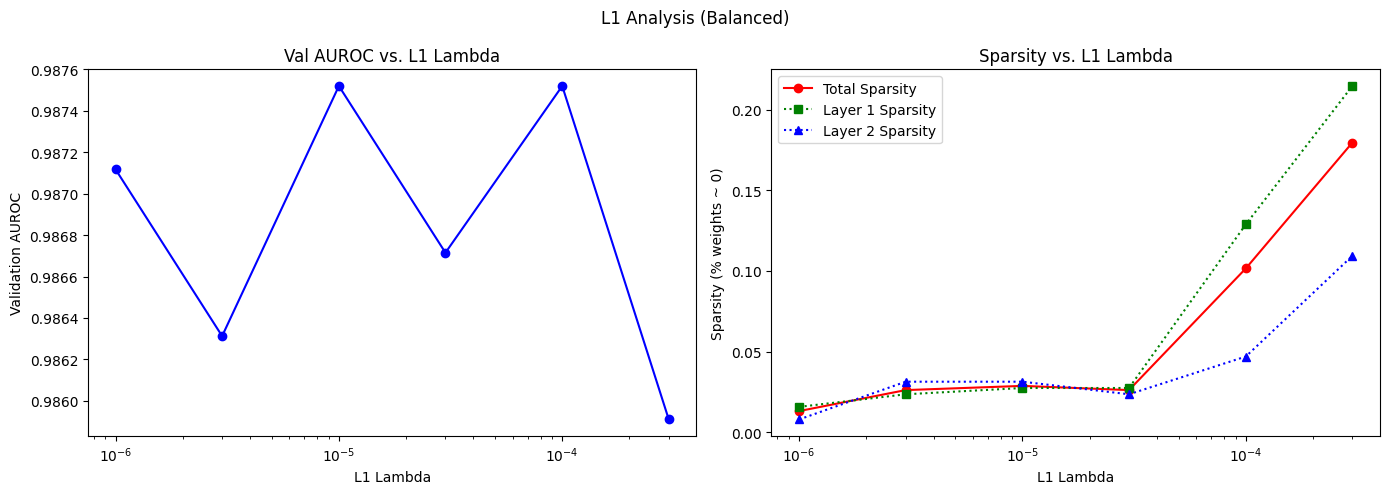


Test Accuracy & Parameter Count (Balanced):
  Model  Params  Test Acc (Noise 0.1)  Test Acc (Noise 0.2)  Test Acc (Noise 0.3)
 MLP-ES     513                0.9940                0.9680                0.9200
 MLP-L1     513                0.9960                0.9720                0.9240
 MLP-L2     513                0.9960                0.9720                0.9240
LR-Poly      10                0.9980                0.9740                0.9200

Generating Decision Boundary Plots (Balanced)...


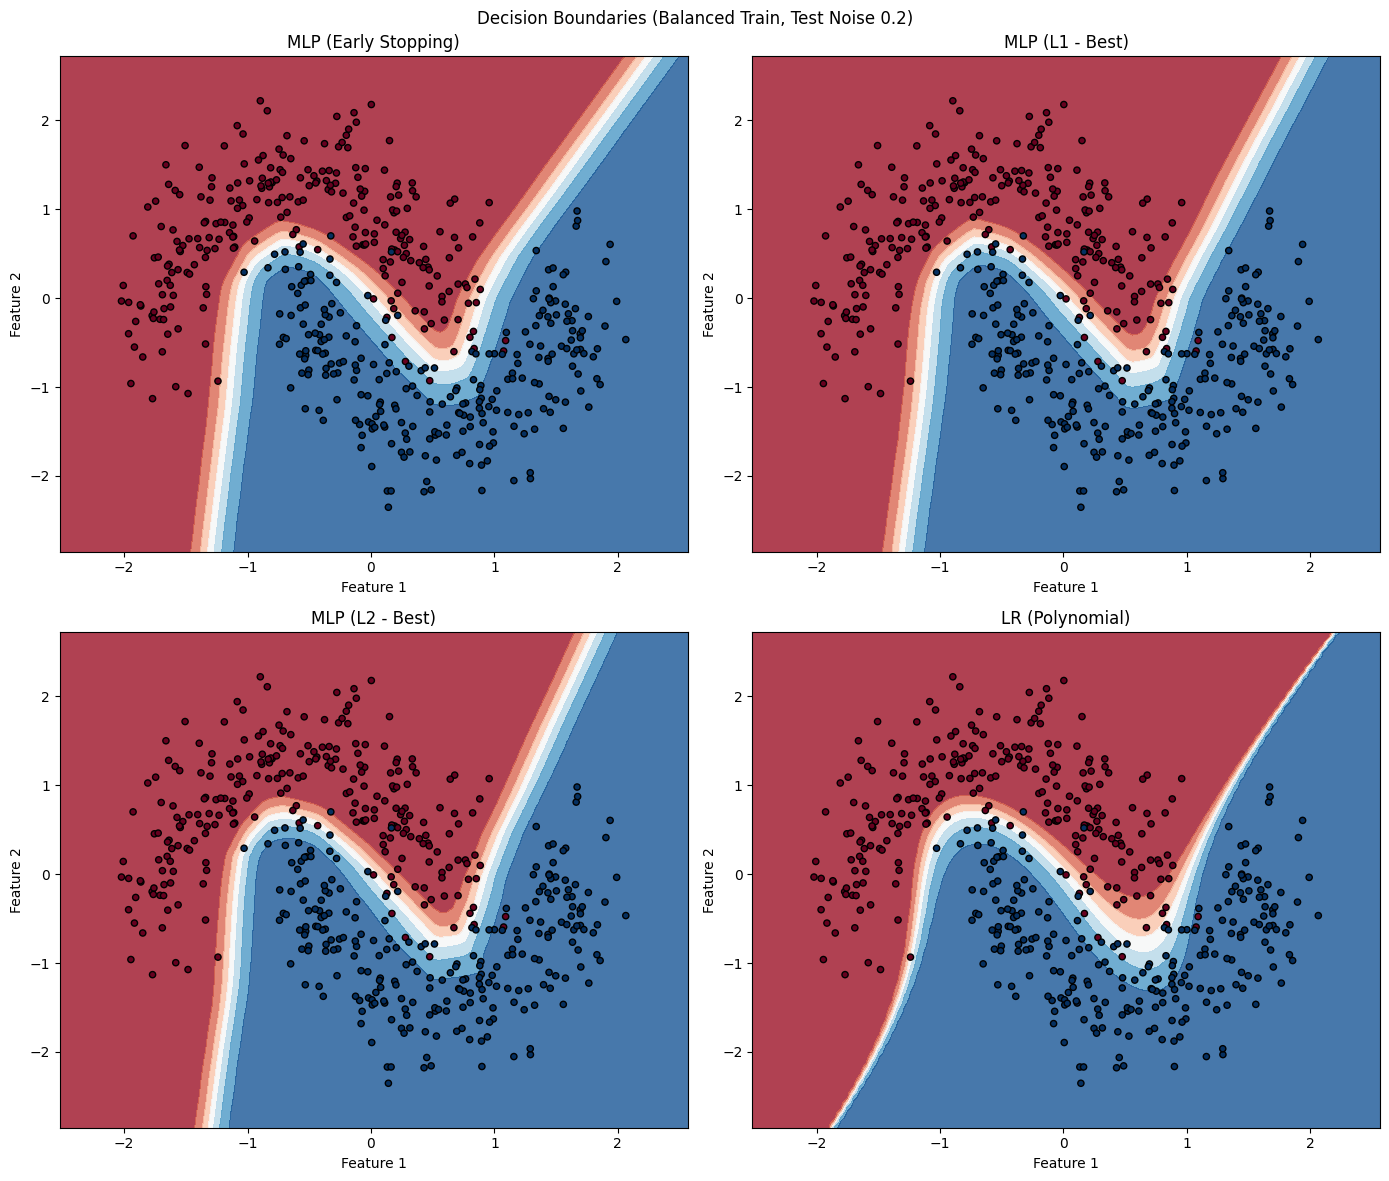

In [14]:
print("--- Starting Balanced Experiment (50:50) ---")

X_train_raw, y_train_raw = make_moons_custom(N_TRAIN, noise=0.2, random_state=RANDOM_SEED)
X_test_02, y_test_02 = make_moons_custom(N_TEST, noise=0.2, random_state=RANDOM_SEED * 2)
X_test_01, y_test_01 = make_moons_custom(N_TEST, noise=0.1, random_state=RANDOM_SEED * 3)
X_test_03, y_test_03 = make_moons_custom(N_TEST, noise=0.3, random_state=RANDOM_SEED * 4)

test_sets_balanced = {
    'noise_0.1': (X_test_01, y_test_01),
    'noise_0.2': (X_test_02, y_test_02),
    'noise_0.3': (X_test_03, y_test_03)
}

models_bal, results_bal, l1_df_bal, test_sets_std_bal = run_experiment(
    X_train_raw, y_train_raw, test_sets_balanced
)

print("\n--- Balanced Experiment Results ---")

print("\nL1 Regularization Analysis (Balanced):")
print(l1_df_bal.to_string(index=False, float_format="%.5f"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(l1_df_bal['lambda'], l1_df_bal['val_auroc'], 'bo-')
ax1.set_xscale('log')
ax1.set_title('Val AUROC vs. L1 Lambda')
ax1.set_xlabel('L1 Lambda')
ax1.set_ylabel('Validation AUROC')

ax2.plot(l1_df_bal['lambda'], l1_df_bal['sparsity_total'], 'ro-', label='Total Sparsity')
ax2.plot(l1_df_bal['lambda'], l1_df_bal['sparsity_l1'], 'g:s', label='Layer 1 Sparsity')
ax2.plot(l1_df_bal['lambda'], l1_df_bal['sparsity_l2'], 'b:^', label='Layer 2 Sparsity')
ax2.set_xscale('log')
ax2.set_title('Sparsity vs. L1 Lambda')
ax2.set_xlabel('L1 Lambda')
ax2.set_ylabel('Sparsity (% weights ~ 0)')
ax2.legend()
fig.suptitle("L1 Analysis (Balanced)")
plt.tight_layout()
plt.show()

acc_data = []
for model_name, res in results_bal.items():
    acc_data.append({
        'Model': model_name,
        'Params': res['param_count'],
        'Test Acc (Noise 0.1)': res['noise_0.1_acc'],
        'Test Acc (Noise 0.2)': res['noise_0.2_acc'],
        'Test Acc (Noise 0.3)': res['noise_0.3_acc']
    })
acc_df_bal = pd.DataFrame(acc_data)
print("\nTest Accuracy & Parameter Count (Balanced):")
print(acc_df_bal.to_string(index=False, float_format="%.4f"))

print("\nGenerating Decision Boundary Plots (Balanced)...")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
(X_test_02_std, y_test_02_std) = test_sets_std_bal['noise_0.2']

plot_decision_boundary(axes[0, 0], models_bal['MLP-ES'][0], X_test_02_std, y_test_02_std, 'MLP (Early Stopping)', is_torch=True)
plot_decision_boundary(axes[0, 1], models_bal['MLP-L1'][0], X_test_02_std, y_test_02_std, 'MLP (L1 - Best)', is_torch=True)
plot_decision_boundary(axes[1, 0], models_bal['MLP-L2'][0], X_test_02_std, y_test_02_std, 'MLP (L2 - Best)', is_torch=True)
plot_decision_boundary(axes[1, 1], models_bal['LR-Poly'][0], X_test_02_std, y_test_02_std, 'LR (Polynomial)', is_torch=False)

fig.suptitle("Decision Boundaries (Balanced Train, Test Noise 0.2)")
plt.tight_layout()
plt.show()


In [15]:
print("\n--- Starting Imbalanced Experiment (70:30) ---")

idx_0 = np.where(y_train_raw == 0)[0]
idx_1 = np.where(y_train_raw == 1)[0]

# N_class_1 = N_class_0 * (30 / 70)
n_class_1_target = int(len(idx_0) * (0.3 / 0.7))
rng = np.random.default_rng(RANDOM_SEED)
idx_1_downsampled = rng.choice(idx_1, size=n_class_1_target, replace=False)

idx_imbalanced = np.concatenate([idx_0, idx_1_downsampled])
X_train_imb_raw = X_train_raw[idx_imbalanced]
y_train_imb_raw = y_train_raw[idx_imbalanced]

print(f"Imbalanced train set created. Class 0: {len(idx_0)} ({(len(idx_0)/len(idx_imbalanced)*100):.1f}%) "
      f"Class 1: {len(idx_1_downsampled)} ({(len(idx_1_downsampled)/len(idx_imbalanced)*100):.1f}%)")

models_imb, results_imb, l1_df_imb, test_sets_std_imb = run_experiment(
    X_train_imb_raw, y_train_imb_raw, test_sets_balanced
)

print("\n--- Imbalanced Experiment Results ---")
imb_report_data = []
for model_name, res in results_imb.items():
    imb_report_data.append({
        'Model': model_name,
        'Test Acc (Noise 0.2)': res['noise_0.2_acc'],
        'Test AUROC (Noise 0.2)': res['noise_0.2_auroc']
    })
imb_df = pd.DataFrame(imb_report_data)
print("\nAccuracy and AUROC on Balanced Test Set (Noise 0.2) after Imbalanced Training:")
print(imb_df.to_string(index=False, float_format="%.4f"))



--- Starting Imbalanced Experiment (70:30) ---
Imbalanced train set created. Class 0: 250 (70.0%) Class 1: 107 (30.0%)
Training Model 1: MLP (Early Stopping)...
Training Model 2: MLP (L1 Grid Search)...
Training Model 3: MLP (L2 Grid Search)...
Training Model 4: Logistic Regression (Poly)...

--- Imbalanced Experiment Results ---

Accuracy and AUROC on Balanced Test Set (Noise 0.2) after Imbalanced Training:
  Model  Test Acc (Noise 0.2)  Test AUROC (Noise 0.2)
 MLP-ES                0.9580                  0.9938
 MLP-L1                0.9540                  0.9929
 MLP-L2                0.9580                  0.9935
LR-Poly                0.9660                  0.9959


## Final Discussion and Analysis

This experiment compared four models on a custom **"make-moons"** dataset, evaluating their accuracy, robustness to noise, and sensitivity to class imbalance.

### 1. Overall Performance (Balanced Dataset)

On the standard balanced dataset (50:50 class split), all four models demonstrated excellent performance.  
The **Logistic Regression with Polynomial Features (LR-Poly)** model was the standout performer, achieving the highest test accuracy on both:

- **Low-noise test set (0.1 noise):** 99.8%  
- **Standard-noise test set (0.2 noise):** 97.4%

A key comparison was **efficiency vs. complexity**:

| Model | Parameters | Result |
|--------|------------|---------|
| MLP-ES / MLP-L1 / MLP-L2 | 513 | High accuracy but over-parameterized |
| LR-Poly (degree 3) | 10 | Best results with far fewer parameters |

This strongly suggests that the nonlinear decision boundary of the moons dataset is well-approximated by a **3rd-degree polynomial**, making the MLPs unnecessarily large for this task.


### 2. Effect of L1 Regularization (Sparsity)

L1 regularization promoted **weight sparsity** in the MLP.

- As λ increased from `1e-6` to `3e-4`, total sparsity grew from **~1.3%** to **~18%**.
- At λ = `0.0003`, almost **1/5 of the weights were zeroed out**.
- Validation AUROC stayed high (**0.986**), proving that pruning did **not** hurt generalization.

Confirms the MLP was **over-parameterized**  
Fewer active weights → more locally linear / jagged boundary


### 3. Effect of L2 Regularization (Smoothness)

The **MLP-L2** model (weight decay):

- Matched the performance of the best L1 model.
- Penalizes large weights → uses **all features slightly** instead of relying on a few.
- Produces a **smoother decision boundary**, with a more stable margin.

Shows L2 is an **equally valid regularization strategy** for this problem.


### 4. Highlight: The Effect of Class Imbalance (70:30)

Models were retrained on a **70:30 imbalanced dataset**, but tested on the original 50:50 balanced test set.

#### Accuracy vs. AUROC
- **Accuracy is misleading** in imbalanced datasets — a model can just predict the majority class.
- **AUROC is preferred**, because it evaluates class separation independent of threshold.

#### Performance Drop (Expected)

| Model | Accuracy Drop |
|--------|---------------|
| MLP-ES | ↓ 1.0% (96.8% → 95.8%) |
| LR-Poly | ↓ 0.8% (97.4% → 96.6%) |

#### Key Insight

Even with imbalance, **AUROC stayed extremely high**:

- MLP-ES AUROC: **0.9938**
- LR-Poly AUROC: **0.9959**

Models learned the structure well and still separated classes effectively  
LR-Poly was the most robust — smallest drop in accuracy *and* highest AUROC


### Final Conclusion

The **LR-Poly model** is the best and most efficient model for this task:

- Highest accuracy and AUROC
- Smallest drop under imbalance
- Uses **~50× fewer parameters** than MLPs
